Accuracy: 0.9991470809340852
Confusion Matrix:
[[   289      0      0      0     95      0      0]
 [     0   1820      0      0      1      0      0]
 [     0      0  25670      0      5      0      0]
 [     0      0      0  38892     16      1      3]
 [    19      0      2     52 418407    215      2]
 [     0      0      0      6      3  18209      1]
 [     0      0      0      0      9      0    434]]
Precision: 0.9872967015464699
Recall: 0.9613983951438311
F1 Score: 0.972884559511965


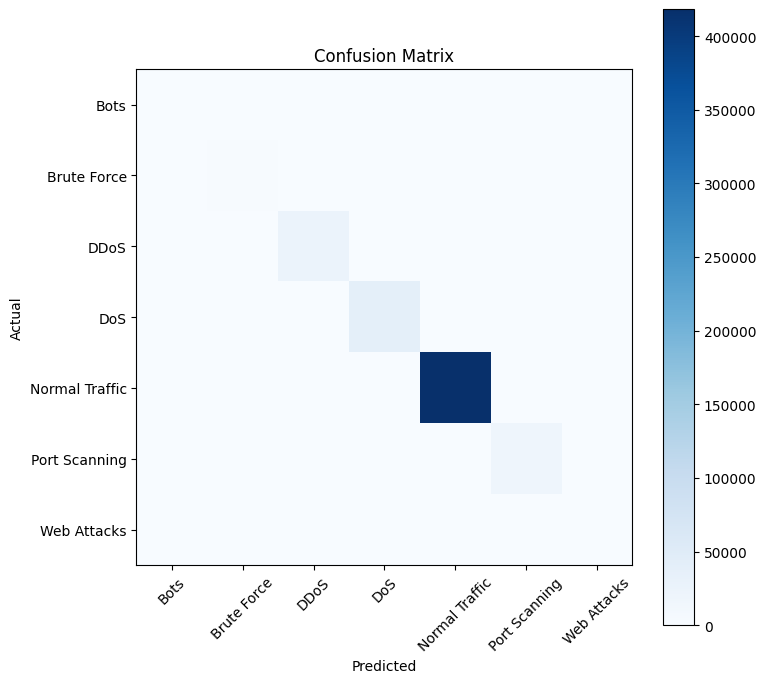

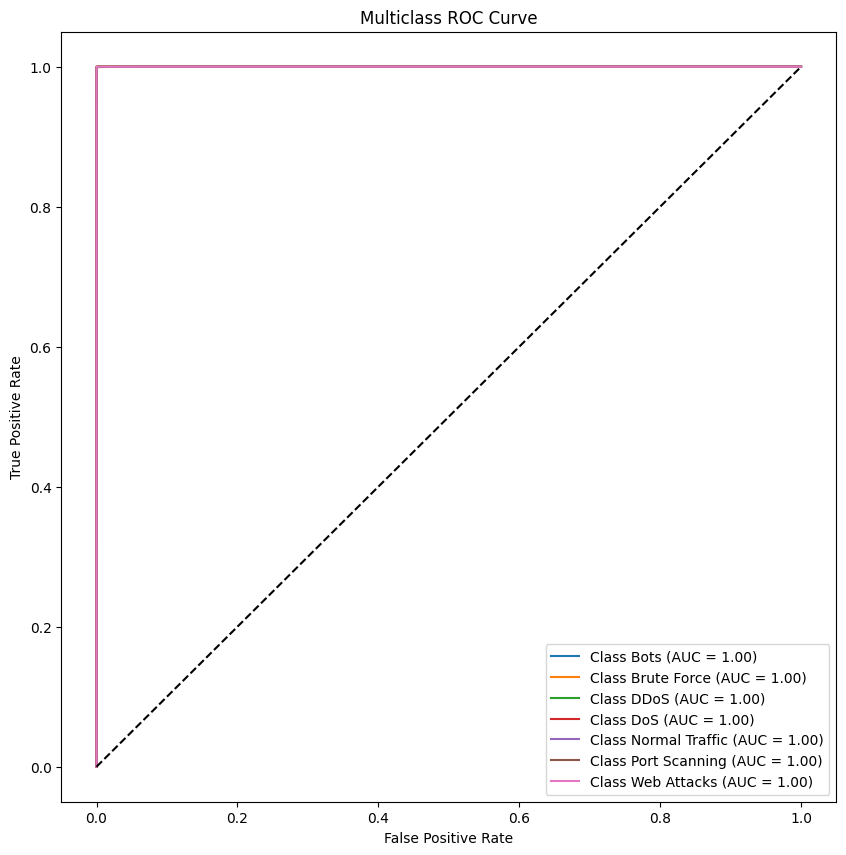

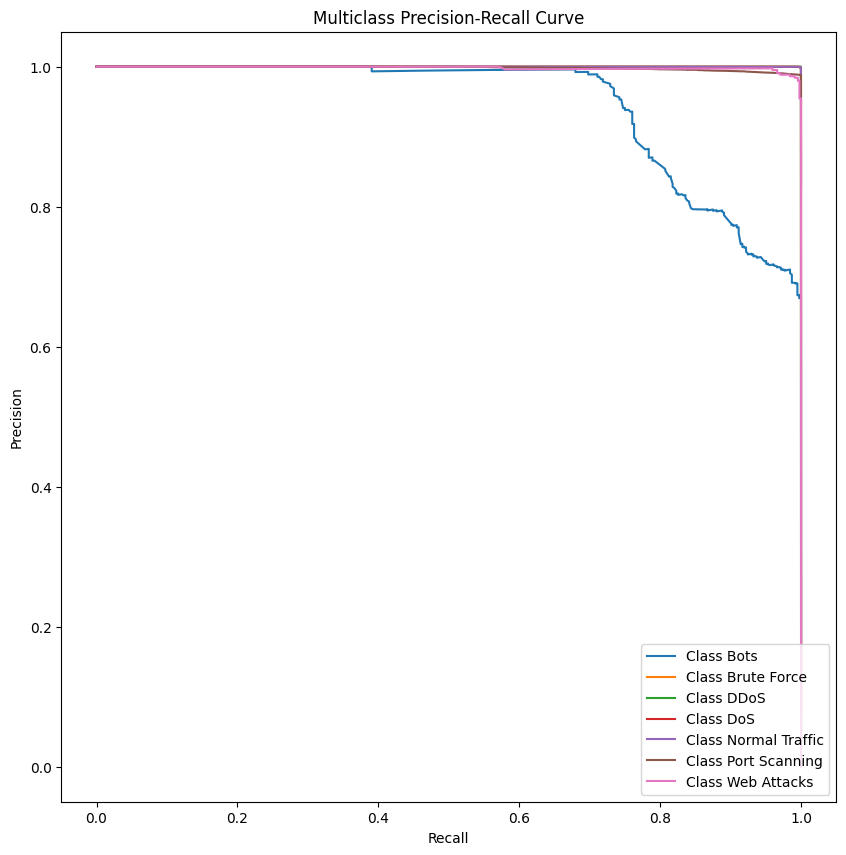

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Load the dataset (replace 'path_to_dataset.csv' with the actual path to your CICIDS 2017 dataset)
data = pd.read_csv('D:\datasets\cicids 2017 cleaned and preprocessed\cicids2017_cleaned.csv')

# Preprocess the data (adjust column names and preprocessing as per your dataset)
X = data.drop('Attack Type', axis=1)  # Features
y = data['Attack Type']  # Target (string labels)

# Encode string labels into integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Get the number of unique classes
num_classes = len(np.unique(y_encoded))

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.20, random_state=42)

# Initialize and train the XGBoost classifier for multiclass classification
model = XGBClassifier(objective='multi:softprob', num_class=num_classes, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')  # Use 'macro' for multiclass tasks
recall = recall_score(y_test, y_pred, average='macro')        # Use 'macro' for multiclass tasks
f1 = f1_score(y_test, y_pred, average='macro')                # Use 'macro' for multiclass tasks

print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# Plot confusion matrix
plt.figure(figsize=(8, 8))
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(np.arange(num_classes), label_encoder.classes_, rotation=45)
plt.yticks(np.arange(num_classes), label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot ROC curve (one vs rest approach for each class)
plt.figure(figsize=(10, 10))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Plot Precision-Recall curve (one vs rest approach for each class)
plt.figure(figsize=(10, 10))
for i in range(num_classes):
    precision_vals, recall_vals, _ = precision_recall_curve((y_test == i).astype(int), y_pred_proba[:, i])
    plt.plot(recall_vals, precision_vals, label=f'Class {label_encoder.classes_[i]}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Multiclass Precision-Recall Curve')
plt.legend(loc='lower right')
plt.show()
